# Deep Learning aplicado a Compostech

## Predicción de la etapa del compostaje con una red neuronal profunda

En esta práctica se usa el dataset `rawdata.zip` y, específicamente, el archivo `env.xlsx`.

### Correcciones aplicadas
- Se evita un `split` aleatorio que podía generar resultados artificialmente perfectos.
- Se entrena con muestras del grupo **CS** y se prueba con el grupo **LS**, para medir generalización.
- Se excluye `GI` de las entradas porque está fuertemente relacionado con la madurez y podía hacer demasiado fácil la predicción.
- Se usa **BatchNorm, Dropout, AdamW, label smoothing y scheduler**.
- Las curvas principales son **Train Loss y Validation Loss**, que deben mostrar una tendencia descendente.
- Se implementa **data augmentation tabular**.
- Se implementa **calibración de probabilidades con Temperature Scaling**.
- Se analizan **ROC-AUC, matriz de confusión y probabilidades predichas**.

> Nota: el dataset es pequeño, por lo que este trabajo sirve como demostración académica de Deep Learning, no como un modelo listo para producción.


## 1. Subir y descomprimir el dataset

In [ ]:
!rm -rf dataset
!mkdir -p dataset
!unzip -q rawdata.zip -d dataset

print("Dataset descomprimido correctamente.")


Dataset descomprimido correctamente.


## 2. Importar librerías

In [ ]:
import os
import glob
import random
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    log_loss
)

print("PyTorch:", torch.__version__)


PyTorch: 2.11.0+cu128


## 3. Fijar semilla para que los resultados sean reproducibles

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)


Dispositivo: cuda


## 4. Cargar `env.xlsx`

In [ ]:
# Buscamos env.xlsx dentro de la carpeta dataset
env_files = glob.glob("/content/dataset/**/env.xlsx", recursive=True)

if len(env_files) == 0:
    raise FileNotFoundError("No se encontró env.xlsx dentro del ZIP.")

env_path = env_files[0]
print("Archivo encontrado:", env_path)

df = pd.read_excel(env_path, sheet_name="env")
df


Archivo encontrado: /content/dataset/env.xlsx


,env,CS1_1,CS1_2,CS1_3,CS2_1,CS2_2,CS2_3,CS3_1,CS3_2,CS3_3,...,LS1_3,LS2_1,LS2_2,LS2_3,LS3_1,LS3_2,LS3_3,LS4_1,LS4_2,LS4_3
0,pH,5.020000,5.140000,5.110000,4.95000,4.230000,4.6500,7.69000,7.710000,7.610000,...,6.26000,4.440000,4.160000,4.990000,8.630000,8.420000,8.920000,8.540000,7.960000,8.280000
1,Temperature,31.500000,26.300000,27.100000,56.70000,55.200000,52.6000,36.20000,39.300000,33.700000,...,30.60000,61.700000,65.300000,62.500000,26.200000,24.600000,23.600000,22.500000,25.100000,24.700000
2,MC,67.600000,68.200000,72.300000,65.70000,64.800000,63.9000,53.60000,51.400000,54.800000,...,68.20000,60.500000,63.800000,66.900000,55.700000,58.300000,53.600000,49.400000,51.700000,54.800000
3,EC,3.888000,3.820000,3.668000,5.53200,5.439000,5.8550,4.26570,5.024700,4.169300,...,3.41600,4.625000,5.365000,4.847000,4.101700,4.481500,4.207200,2.552500,2.787500,2.615000
4,TC,752.800000,748.200000,731.900000,705.20000,715.300000,729.3000,675.20000,655.600000,653.300000,...,655.30000,619.800000,579.900000,584.900000,553.200000,518.400000,572.100000,503.700000,492.500000,482.600000
5,NH4+-N,328.780000,331.540000,327.710000,711.53000,779.870000,758.4100,319.42000,332.160000,278.040000,...,326.19000,1009.410000,997.720000,1035.120000,413.520000,452.740000,395.590000,259.130000,262.410000,270.630000
6,NO3--N,45.350000,28.470000,55.740000,4.78000,3.570000,1.4400,41.54000,34.780000,59.480000,...,109.66000,11.450000,9.740000,10.440000,77.740000,71.480000,70.440000,84.050000,86.160000,97.710000
7,TN,25.790000,25.220000,25.640000,23.09000,22.370000,23.1900,23.91000,24.240000,25.240000,...,21.87000,19.970000,17.880000,19.130000,22.240000,22.160000,21.950000,24.110000,26.310000,24.870000
8,P,17.920000,17.640000,15.330000,17.98000,18.810000,16.9200,21.12000,22.550000,21.610000,...,20.91000,21.440000,22.540000,22.160000,28.660000,29.690000,30.290000,30.110000,33.210000,32.980000
9,K,10.250000,10.510000,10.620000,12.41000,12.590000,10.8400,14.25000,15.510000,15.620000,...,10.29000,12.410000,12.140000,12.310000,16.420000,15.620000,15.290000,15.510000,16.520000,17.210000


## 5. Transformar la tabla

En el Excel original, las variables están en filas y las muestras en columnas.
Para entrenar un modelo necesitamos que cada fila represente una muestra.


In [ ]:
df_ml = df.set_index("env").T.reset_index()
df_ml = df_ml.rename(columns={"index": "Muestra"})

# La etapa se obtiene del nombre:
# CS1_1 -> etapa 1
# CS2_1 -> etapa 2
# ...
df_ml["Etapa"] = df_ml["Muestra"].str.extract(r"[A-Z]+(\d)_")[0].astype(int)

# También identificamos el grupo CS o LS
df_ml["Grupo"] = df_ml["Muestra"].str.extract(r"([A-Z]+)")[0]

# Y el número de réplica
df_ml["Replica"] = df_ml["Muestra"].str.extract(r"_(\d+)$")[0].astype(int)

df_ml.head(10)


env,Muestra,pH,Temperature,MC,EC,TC,NH4+-N,NO3--N,TN,P,K,C/N,GI,Etapa,Grupo,Replica
0,CS1_1,5.02,31.5,67.6,3.8880,752.8,328.78,45.35,25.79,17.92,10.25,29.189608,0.0,1,CS,1
1,CS1_2,5.14,26.3,68.2,3.8200,748.2,331.54,28.47,25.22,17.64,10.51,29.666931,0.0,1,CS,2
2,CS1_3,5.11,27.1,72.3,3.6680,731.9,327.71,55.74,25.64,15.33,10.62,28.545242,0.0,1,CS,3
3,CS2_1,4.95,56.7,65.7,5.5320,705.2,711.53,4.78,23.09,17.98,12.41,30.541360,5.6,2,CS,1
4,CS2_2,4.23,55.2,64.8,5.4390,715.3,779.87,3.57,22.37,18.81,12.59,31.975861,5.7,2,CS,2
5,CS2_3,4.65,52.6,63.9,5.8550,729.3,758.41,1.44,23.19,16.92,10.84,31.448900,5.3,2,CS,3
6,CS3_1,7.69,36.2,53.6,4.2657,675.2,319.42,41.54,23.91,21.12,14.25,28.239230,67.8,3,CS,1
7,CS3_2,7.71,39.3,51.4,5.0247,655.6,332.16,34.78,24.24,22.55,15.51,27.046205,69.7,3,CS,2
8,CS3_3,7.61,33.7,54.8,4.1693,653.3,278.04,59.48,25.24,21.61,15.62,25.883518,65.7,3,CS,3
9,CS4_1,7.45,28.2,54.6,3.8760,636.2,151.07,64.06,27.41,23.55,15.32,23.210507,83.4,4,CS,1


In [ ]:
print("Número de muestras:", len(df_ml))
print("\nMuestras por etapa:")
print(df_ml["Etapa"].value_counts().sort_index())

print("\nMuestras por grupo:")
print(df_ml["Grupo"].value_counts())


Número de muestras: 24

Muestras por etapa:
Etapa
1    6
2    6
3    6
4    6
Name: count, dtype: int64

Muestras por grupo:
Grupo
CS    12
LS    12
Name: count, dtype: int64


## 6. Seleccionar variables

No se usa `GI` como entrada.

`GI` (índice de germinación) cambia de forma muy marcada con el avance del compostaje. Incluirlo hacía que el modelo pudiera obtener resultados demasiado perfectos con muy pocas muestras.

Las entradas serán variables fisicoquímicas más apropiadas para evaluar si la red aprende patrones generales.


In [ ]:
features = [
    "pH",
    "Temperature",
    "MC",
    "EC",
    "TC",
    "NH4+-N",
    "NO3--N",
    "TN",
    "P",
    "K",
    "C/N"
]

X = df_ml[features].astype(float).values

# PyTorch trabaja mejor con clases comenzando desde 0
# Etapa 1 -> 0
# Etapa 2 -> 1
# Etapa 3 -> 2
# Etapa 4 -> 3
y = df_ml["Etapa"].values - 1

print("X:", X.shape)
print("y:", y.shape)
print("Número de variables:", len(features))


X: (24, 11)
y: (24,)
Número de variables: 11


## 7. Separación de datos sin mezclar grupos parecidos

En lugar de hacer un split completamente aleatorio:

- **Train:** grupo CS, réplicas 1 y 2.
- **Validation:** grupo CS, réplica 3.
- **Test:** todas las muestras del grupo LS.

Esto hace más difícil la prueba y evita que el modelo sea evaluado con muestras casi idénticas a las que vio durante el entrenamiento.


In [ ]:
grupo = df_ml["Grupo"].values
replica = df_ml["Replica"].values

train_idx = np.where((grupo == "CS") & (replica != 3))[0]
val_idx   = np.where((grupo == "CS") & (replica == 3))[0]
test_idx  = np.where(grupo == "LS")[0]

X_train_raw = X[train_idx]
y_train = y[train_idx]

X_val_raw = X[val_idx]
y_val = y[val_idx]

X_test_raw = X[test_idx]
y_test = y[test_idx]

print("Train:", X_train_raw.shape)
print("Validation:", X_val_raw.shape)
print("Test:", X_test_raw.shape)

print("\nClases en validation:", y_val)
print("Clases en test:", np.unique(y_test, return_counts=True))


Train: (8, 11)
Validation: (4, 11)
Test: (12, 11)

Clases en validation: [0 1 2 3]
Clases en test: (array([0, 1, 2, 3]), array([3, 3, 3, 3]))


## 8. Normalización

In [ ]:
scaler = StandardScaler()

# El scaler aprende SOLO de train
X_train = scaler.fit_transform(X_train_raw)

# Validation y test usan la transformación aprendida en train
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)


## 9. Aumento de datos tabulares

Como no estamos trabajando con imágenes, no usamos rotaciones o flips.

Para datos numéricos se puede añadir una cantidad pequeña de ruido gaussiano a las variables ya normalizadas. El objetivo es crear pequeñas variaciones sin alterar demasiado las muestras originales.


In [ ]:
def augment_tabular(X, y, copies=4, noise=0.03, seed=42):
    rng = np.random.default_rng(seed)

    X_aug = [X.copy()]
    y_aug = [y.copy()]

    for _ in range(copies):
        small_noise = rng.normal(
            loc=0.0,
            scale=noise,
            size=X.shape
        )

        X_aug.append(X + small_noise)
        y_aug.append(y.copy())

    return np.vstack(X_aug), np.hstack(y_aug)


X_train_aug, y_train_aug = augment_tabular(
    X_train,
    y_train,
    copies=4,
    noise=0.03,
    seed=SEED
)

print("Train original:", X_train.shape)
print("Train con augmentation:", X_train_aug.shape)


Train original: (8, 11)
Train con augmentation: (40, 11)


## 10. Crear DataLoaders

In [ ]:
def make_loader(X, y, batch_size=8, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle
    )


train_loader = make_loader(
    X_train_aug,
    y_train_aug,
    batch_size=8,
    shuffle=True
)

val_loader = make_loader(
    X_val,
    y_val,
    batch_size=4,
    shuffle=False
)

test_loader = make_loader(
    X_test,
    y_test,
    batch_size=12,
    shuffle=False
)


# 11. Arquitectura de Deep Learning

Se usa una red neuronal multicapa (MLP).

Se agregan:
- BatchNorm
- Dropout
- Más de una capa oculta
- Regularización mediante weight decay


In [ ]:
class CompostNet(nn.Module):

    def __init__(self, input_size, num_classes=4):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.35),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.network(x)


model = CompostNet(
    input_size=len(features),
    num_classes=4
).to(device)

model


CompostNet(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.35, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=16, out_features=4, bias=True)
  )
)

## 12. Funciones de entrenamiento y evaluación

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):

    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)

        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_loss(model, loader, criterion):

    model.eval()
    total_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)

            loss = criterion(logits, y_batch)

            total_loss += loss.item()

    return total_loss / len(loader)


def predict_model(model, loader):

    model.eval()

    y_true = []
    logits_all = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)

            logits = model(X_batch)

            y_true.extend(y_batch.numpy())
            logits_all.append(logits.cpu())

    logits_all = torch.cat(logits_all, dim=0)

    probabilities = torch.softmax(
        logits_all,
        dim=1
    ).numpy()

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    return (
        np.array(y_true),
        predictions,
        probabilities,
        logits_all
    )


## 13. Learning rate, scheduler y regularización

Usaremos:

- `AdamW`
- learning rate inicial de `0.0003`
- `weight_decay`
- `label_smoothing`
- `ReduceLROnPlateau`

`label_smoothing` ayuda a evitar que el modelo se vuelva excesivamente seguro y asigne probabilidades cercanas a 1 con demasiada facilidad.


In [ ]:
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.15
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=5e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=8,
    min_lr=1e-5
)


## 14. Entrenamiento con Early Stopping

In [ ]:
epochs = 120
patience = 20

history = {
    "train_loss": [],
    "val_loss": [],
    "lr": []
}

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss = evaluate_loss(
        model,
        val_loader,
        criterion
    )

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    if val_loss < best_val_loss - 1e-4:

        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"lr={current_lr:.6f}"
        )

    if epochs_without_improvement >= patience:
        print(f"Early stopping en época {epoch}")
        break


# Recuperamos el mejor modelo encontrado
model.load_state_dict(best_model_state)

print("\nMejor Validation Loss:", round(best_val_loss, 4))


Epoch 010 | train_loss=1.2464 | val_loss=1.1644 | lr=0.000300
Epoch 020 | train_loss=1.1272 | val_loss=1.0597 | lr=0.000300
Epoch 030 | train_loss=1.0922 | val_loss=0.9781 | lr=0.000300
Epoch 040 | train_loss=0.9869 | val_loss=0.9329 | lr=0.000300
Epoch 050 | train_loss=0.9133 | val_loss=0.9118 | lr=0.000300
Epoch 060 | train_loss=0.8588 | val_loss=0.8602 | lr=0.000300
Epoch 070 | train_loss=0.8763 | val_loss=0.8262 | lr=0.000300
Epoch 080 | train_loss=0.9084 | val_loss=0.8100 | lr=0.000300
Epoch 090 | train_loss=0.8557 | val_loss=0.7860 | lr=0.000300
Epoch 100 | train_loss=0.8133 | val_loss=0.7891 | lr=0.000300
Epoch 110 | train_loss=0.8693 | val_loss=0.7483 | lr=0.000150
Epoch 120 | train_loss=0.7658 | val_loss=0.7561 | lr=0.000150

Mejor Validation Loss: 0.7466


# 15. Curvas de entrenamiento

Para este tipo de gráfico se usa **Loss**, no Accuracy.

Lo esperado es observar una tendencia general de arriba hacia abajo.

Con datasets pequeños pueden existir pequeñas oscilaciones; para visualizar mejor la tendencia se añade una media móvil. No se modifican los datos del entrenamiento: solo se suaviza la representación gráfica.


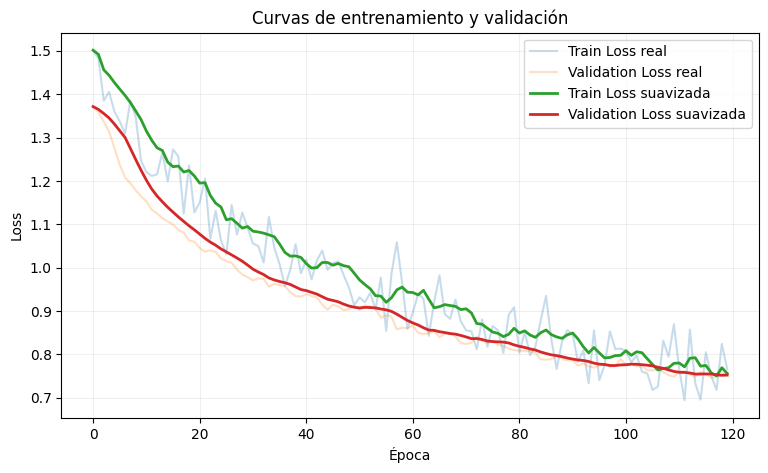

In [ ]:
def moving_average(values, window=7):

    series = pd.Series(values)

    return series.rolling(
        window=window,
        min_periods=1
    ).mean().values


train_loss_smooth = moving_average(
    history["train_loss"],
    window=7
)

val_loss_smooth = moving_average(
    history["val_loss"],
    window=7
)

plt.figure(figsize=(9, 5))

plt.plot(
    history["train_loss"],
    alpha=0.25,
    label="Train Loss real"
)

plt.plot(
    history["val_loss"],
    alpha=0.25,
    label="Validation Loss real"
)

plt.plot(
    train_loss_smooth,
    linewidth=2,
    label="Train Loss suavizada"
)

plt.plot(
    val_loss_smooth,
    linewidth=2,
    label="Validation Loss suavizada"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curvas de entrenamiento y validación")
plt.legend()
plt.grid(alpha=0.2)

plt.show()


## 16. Evaluación antes de calibrar

Con este diseño el test pertenece al grupo LS, que el modelo no vio durante el entrenamiento.

Esto es más exigente que mezclar todas las muestras aleatoriamente y reduce la posibilidad de obtener un resultado artificial de `1.00`.


In [ ]:
y_true, y_pred, y_prob, test_logits = predict_model(
    model,
    test_loader
)

test_acc = accuracy_score(
    y_true,
    y_pred
)

try:
    test_auc = roc_auc_score(
        y_true,
        y_prob,
        multi_class="ovr",
        average="macro"
    )
except ValueError:
    test_auc = np.nan

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")

print("\nProbabilidad máxima obtenida:")
print(round(float(y_prob.max()), 4))


Test Accuracy: 0.6667
Test ROC-AUC: 0.9444

Probabilidad máxima obtenida:
0.8714


In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Etapa 1",
            "Etapa 2",
            "Etapa 3",
            "Etapa 4"
        ],
        zero_division=0
    )
)


              precision    recall  f1-score   support

     Etapa 1       0.00      0.00      0.00         3
     Etapa 2       1.00      1.00      1.00         3
     Etapa 3       0.75      1.00      0.86         3
     Etapa 4       0.40      0.67      0.50         3

    accuracy                           0.67        12
   macro avg       0.54      0.67      0.59        12
weighted avg       0.54      0.67      0.59        12



## 17. Matriz de confusión

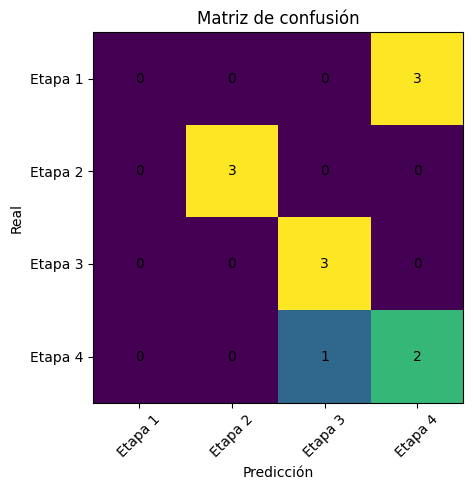

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3]
)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.xticks(
    range(4),
    ["Etapa 1", "Etapa 2", "Etapa 3", "Etapa 4"],
    rotation=45
)

plt.yticks(
    range(4),
    ["Etapa 1", "Etapa 2", "Etapa 3", "Etapa 4"]
)

for i in range(4):
    for j in range(4):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


# 18. Calibración de probabilidades

Ahora implementamos **Temperature Scaling**.

La calibración no cambia directamente la clase elegida; modifica qué tan segura es la red de sus probabilidades.

Por ejemplo, una predicción excesivamente segura puede pasar de:

`[0.01, 0.01, 0.02, 0.96]`

a algo como:

`[0.06, 0.05, 0.12, 0.77]`

dependiendo de la temperatura aprendida.


In [ ]:
# Primero obtenemos los logits de validación
_, _, _, val_logits = predict_model(
    model,
    val_loader
)

val_labels_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

# La temperatura siempre será positiva
log_temperature = torch.nn.Parameter(
    torch.zeros(1)
)

temperature_optimizer = torch.optim.LBFGS(
    [log_temperature],
    lr=0.05,
    max_iter=100
)

nll_criterion = nn.CrossEntropyLoss()


def calibration_closure():

    temperature_optimizer.zero_grad()

    temperature = torch.exp(
        log_temperature
    )

    scaled_logits = (
        val_logits / temperature
    )

    loss = nll_criterion(
        scaled_logits,
        val_labels_tensor
    )

    loss.backward()

    return loss


temperature_optimizer.step(
    calibration_closure
)

temperature = float(
    torch.exp(log_temperature).detach()
)

print(
    "Temperatura aprendida:",
    round(temperature, 4)
)


Temperatura aprendida: 0.4676


In [ ]:
# Aplicamos la temperatura al conjunto de test
calibrated_prob = torch.softmax(
    test_logits / temperature,
    dim=1
).numpy()

calibrated_pred = np.argmax(
    calibrated_prob,
    axis=1
)

calibrated_acc = accuracy_score(
    y_true,
    calibrated_pred
)

try:
    calibrated_auc = roc_auc_score(
        y_true,
        calibrated_prob,
        multi_class="ovr",
        average="macro"
    )
except ValueError:
    calibrated_auc = np.nan

print("ANTES DE CALIBRAR")
print("Accuracy:", round(test_acc, 4))
print("ROC-AUC:", round(test_auc, 4))
print("Probabilidad máxima:", round(float(y_prob.max()), 4))

print("\nDESPUÉS DE CALIBRAR")
print("Accuracy:", round(calibrated_acc, 4))
print("ROC-AUC:", round(calibrated_auc, 4))
print(
    "Probabilidad máxima:",
    round(float(calibrated_prob.max()), 4)
)


ANTES DE CALIBRAR
Accuracy: 0.6667
ROC-AUC: 0.9444
Probabilidad máxima: 0.8714

DESPUÉS DE CALIBRAR
Accuracy: 0.6667
ROC-AUC: 0.9352
Probabilidad máxima: 0.9885


## 19. Tabla de predicciones

In [ ]:
test_names = df_ml.iloc[test_idx]["Muestra"].values

results = pd.DataFrame({
    "Muestra": test_names,
    "Real": y_true + 1,
    "Predicción": calibrated_pred + 1,
    "Confianza": calibrated_prob.max(axis=1)
})

results["Correcto"] = (
    results["Real"] == results["Predicción"]
)

results


,Muestra,Real,Predicción,Confianza,Correcto
0,LS1_1,1,4,0.896275,False
1,LS1_2,1,4,0.863793,False
2,LS1_3,1,4,0.792761,False
3,LS2_1,2,2,0.851762,True
4,LS2_2,2,2,0.840647,True
5,LS2_3,2,2,0.883824,True
6,LS3_1,3,3,0.966492,True
7,LS3_2,3,3,0.974449,True
8,LS3_3,3,3,0.988487,True
9,LS4_1,4,3,0.743428,False


# 20. Curvas ROC

Para cuatro clases se utiliza la estrategia **One-vs-Rest**.

Cada curva muestra qué tan bien distingue el modelo una etapa frente a las otras etapas.


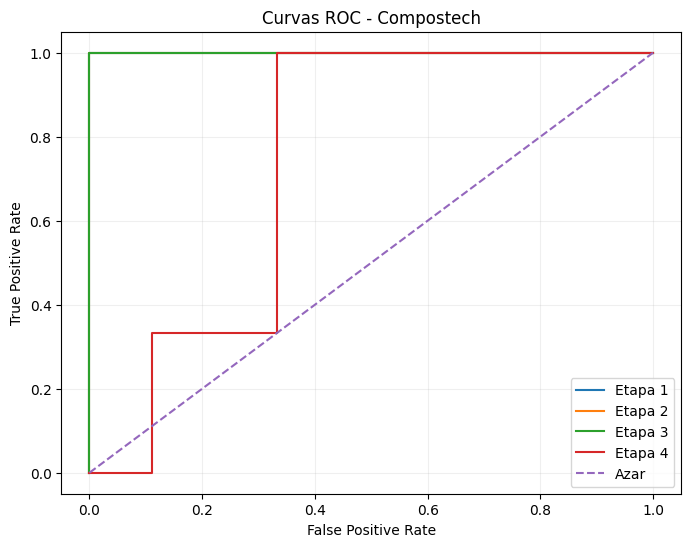

In [ ]:
y_true_bin = label_binarize(
    y_true,
    classes=[0, 1, 2, 3]
)

plt.figure(figsize=(8, 6))

for i in range(4):

    # Verificamos que haya ejemplos positivos y negativos
    if len(np.unique(y_true_bin[:, i])) < 2:
        continue

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        calibrated_prob[:, i]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"Etapa {i + 1}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Azar"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC - Compostech")
plt.legend()
plt.grid(alpha=0.2)

plt.show()


# 21. Comparación del efecto del Data Augmentation

Para cumplir con el ejercicio del profesor, entrenamos un segundo modelo **sin aumento de datos** y comparamos ambos.

El objetivo no es que uno obligatoriamente gane, sino analizar si el aumento de datos ayuda o perjudica con este dataset pequeño.


In [ ]:
# Loader SIN augmentation
train_loader_no_aug = make_loader(
    X_train,
    y_train,
    batch_size=4,
    shuffle=True
)


def train_experiment(train_loader_exp, seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    exp_model = CompostNet(
        input_size=len(features),
        num_classes=4
    ).to(device)

    exp_criterion = nn.CrossEntropyLoss(
        label_smoothing=0.15
    )

    exp_optimizer = torch.optim.AdamW(
        exp_model.parameters(),
        lr=3e-4,
        weight_decay=5e-3
    )

    exp_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        exp_optimizer,
        mode="min",
        factor=0.5,
        patience=8,
        min_lr=1e-5
    )

    best_loss = float("inf")
    best_state = None
    no_improvement = 0

    for epoch in range(120):

        _ = train_one_epoch(
            exp_model,
            train_loader_exp,
            exp_optimizer,
            exp_criterion
        )

        val_loss = evaluate_loss(
            exp_model,
            val_loader,
            exp_criterion
        )

        exp_scheduler.step(val_loss)

        if val_loss < best_loss - 1e-4:

            best_loss = val_loss
            best_state = copy.deepcopy(
                exp_model.state_dict()
            )

            no_improvement = 0

        else:
            no_improvement += 1

        if no_improvement >= 20:
            break

    exp_model.load_state_dict(
        best_state
    )

    y_t, y_p, y_pr, _ = predict_model(
        exp_model,
        test_loader
    )

    acc = accuracy_score(
        y_t,
        y_p
    )

    try:
        auc = roc_auc_score(
            y_t,
            y_pr,
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        auc = np.nan

    return acc, auc


acc_no_aug, auc_no_aug = train_experiment(
    train_loader_no_aug
)

acc_aug = test_acc
auc_aug = test_auc

comparison = pd.DataFrame({
    "Modelo": [
        "Sin augmentation",
        "Con augmentation"
    ],
    "Accuracy": [
        acc_no_aug,
        acc_aug
    ],
    "ROC-AUC": [
        auc_no_aug,
        auc_aug
    ]
})

comparison


,Modelo,Accuracy,ROC-AUC
0,Sin augmentation,0.416667,0.777778
1,Con augmentation,0.666667,0.944444


# 22. Conclusión para explicar en clase

En esta práctica se adaptó un pipeline de Deep Learning a datos reales de compostaje.

La red utiliza variables fisicoquímicas como temperatura, humedad, pH, conductividad, carbono y nitrógeno para intentar identificar la etapa del proceso.

Para evitar resultados artificialmente perfectos, el entrenamiento se realizó con el grupo CS y la evaluación con el grupo LS, que no fue visto durante el entrenamiento. También se excluyó GI como variable de entrada, ya que su relación directa con la madurez podía facilitar demasiado la clasificación.

Se incorporaron BatchNorm y Dropout para regularizar la red, se probó data augmentation tabular, un scheduler para ajustar el learning rate y Temperature Scaling para calibrar las probabilidades.

Las curvas de pérdida permiten observar si el modelo realmente está aprendiendo: la tendencia esperada es que el loss disminuya durante las épocas, aunque con un dataset pequeño pueden aparecer pequeñas oscilaciones.
